# 05 — The money story: 86% revenue capture, honestly measured

**The experiment:** walk forward through all **57 out-of-sample days** (2024-05-04 → 2024-06-29). Every morning, the governed agent commits a full day's schedule using only its quantile forecast and yesterday's ancillary prices. Then reality arrives, and the schedule **settles at the prices that actually occurred.** No retrading, no hindsight, no leakage — the schedule was fixed before the future happened.

Three policies, identical battery (100 MW / 200 MWh), identical physics:

| Policy | Sees | Role |
|---|---|---|
| **Perfect foresight** | tomorrow's realized prices | unreachable ceiling — honest scaling |
| **Governed (this system)** | conformal quantile forecast + persistence AS prices | the agent under evaluation |
| **Naive** | the training window's average day, energy only | the floor any model must beat |

## The scoreboard

| | Settled revenue | vs ceiling |
|---|---|---|
| Perfect foresight | $3.85M | 100% |
| **Governed** | **$3.31M** | **86.1%** |
| Naive | $0.61M | 15.7% |

That is **86.1% revenue capture** and a **+447% uplift over the naive floor** — on a ~57-day window that annualizes to roughly $21M for this asset (indicative, single season).

In [1]:
import json
import pandas as pd

from forecast_to_dispatch.config import load_config, resolve_path
from forecast_to_dispatch.viz.style import apply_style
from forecast_to_dispatch.viz import backtest_viz

config = load_config()
apply_style()
processed = resolve_path(config, "processed")

summary = json.loads((processed / "backtest_results.json").read_text())
daily = pd.read_parquet(processed / "backtest_daily.parquet")
governed_schedule = pd.read_parquet(processed / "backtest_governed_schedule.parquet")
print(f"{summary['n_days']} days | governed ${summary['totals']['governed']:,.0f} | "
      f"capture {summary['revenue_capture_pct']:.1f}%")

57 days | governed $3,313,731 | capture 86.1%


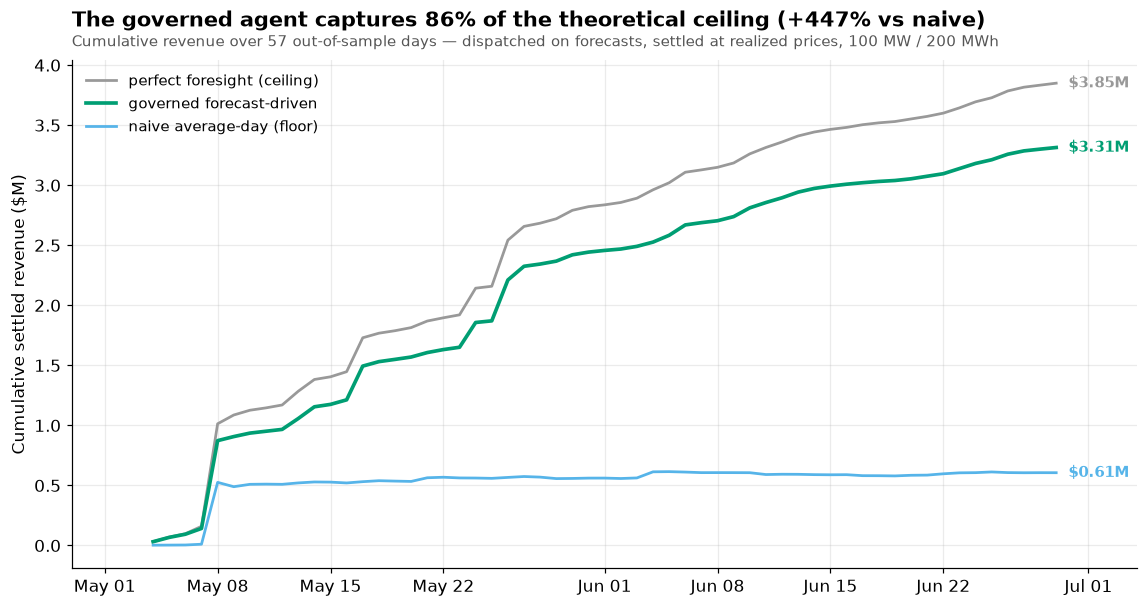

In [2]:
fig = backtest_viz.fig07_cumulative_revenue(daily, summary)

### Interpretation — fig07 (the headline chart)

The governed line tracks the ceiling closely and pulls away from the naive floor immediately and permanently — this is capability, not luck. The vertical jumps are spike days: notice the ceiling and the governed line jump *together* (the agent was positioned) while the naive line barely moves (it had no idea). **Business consequence:** 86% of the theoretically available value, realized with honest day-ahead information — the single number a hiring manager or asset owner should quote from this repository.

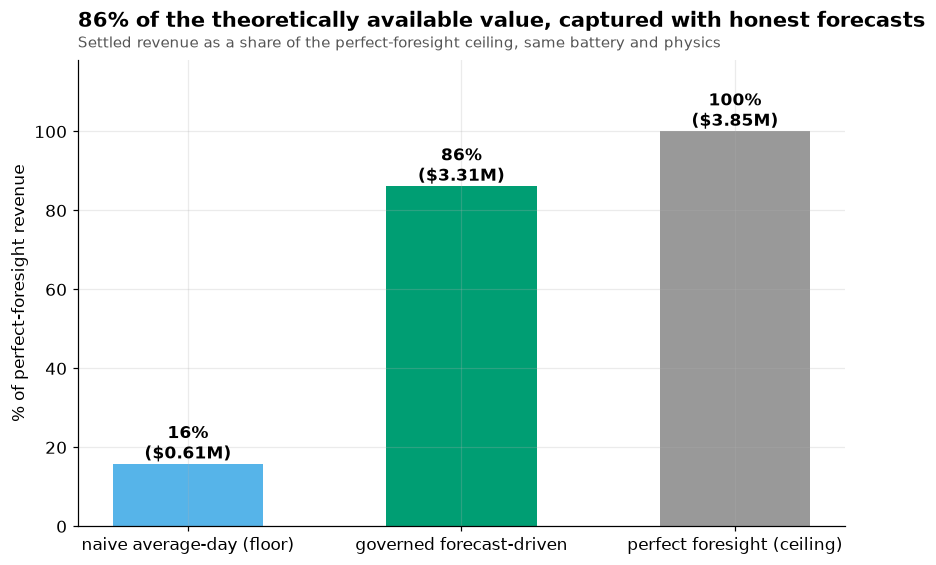

In [3]:
fig = backtest_viz.fig08_revenue_capture_bar(summary)

### Interpretation — fig08

Same result, one glance: the naive strategy captures 16% of available value, the governed agent 86%. The remaining 14% is the irreducible price of not knowing the future — quantified in fig10 rather than hidden. **Business consequence:** the model's contribution is the distance between the first two bars; the honesty of the method is the visible existence of the third.

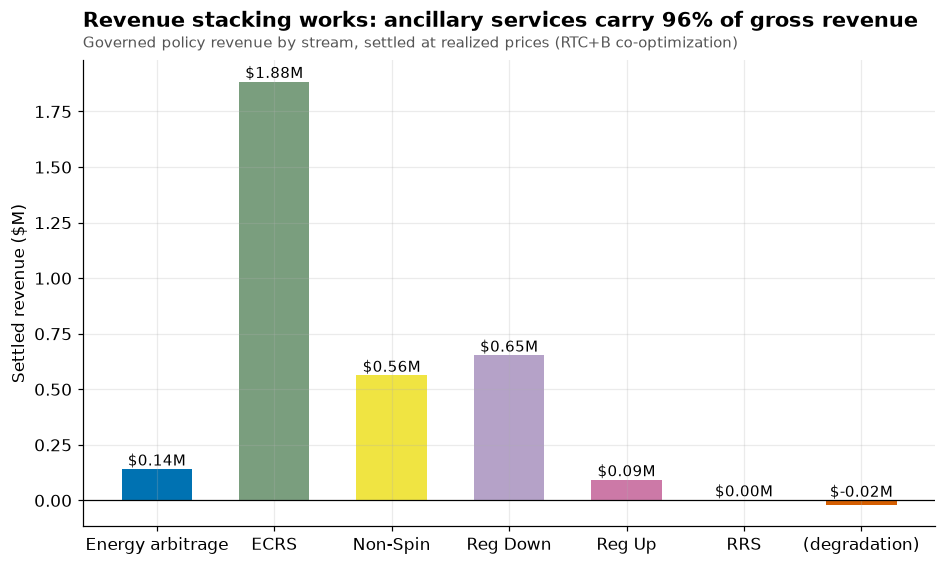

In [4]:
fig = backtest_viz.fig09_revenue_stack(summary)

### Interpretation — fig09

Revenue stacking under RTC+B, settled at real prices: ancillary services carried **96%** of gross revenue (ECRS $1.88M and Reg-Down $0.65M leading), energy arbitrage $0.14M, degradation cost $-21k. Reserve prices are strongly autocorrelated day-over-day, so even the persistence forecast captures them well — while the energy spikes are where perfect foresight out-earns everyone. **Business consequence:** an energy-only battery model would have left roughly 96% of this asset's value on the table; co-optimization is not a refinement, it is most of the product.

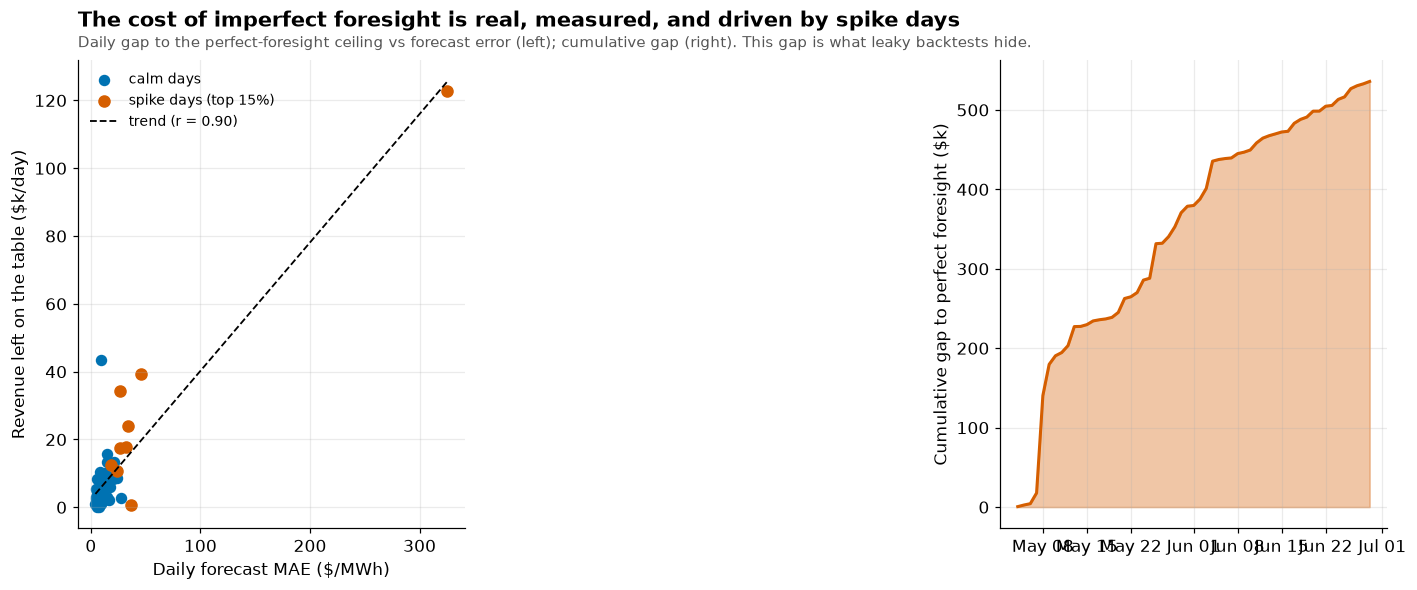

In [5]:
fig = backtest_viz.fig10_cost_of_imperfection(daily)

### Interpretation — fig10

The gap to perfect foresight is not noise: it correlates with daily forecast error (r = 0.90) and concentrates brutally — the worst **5 days carry 49%** of the entire cumulative gap. Those are the spike days where the P95 saw *elevated* risk but not the full magnitude. **Business consequence:** this chart prices the profit-overestimation trap — a leaky backtest silently books this gap as revenue. Ours reports it, which is exactly what makes the 86% defensible; it also says where the next modeling dollar goes (tail magnitude, not average accuracy).

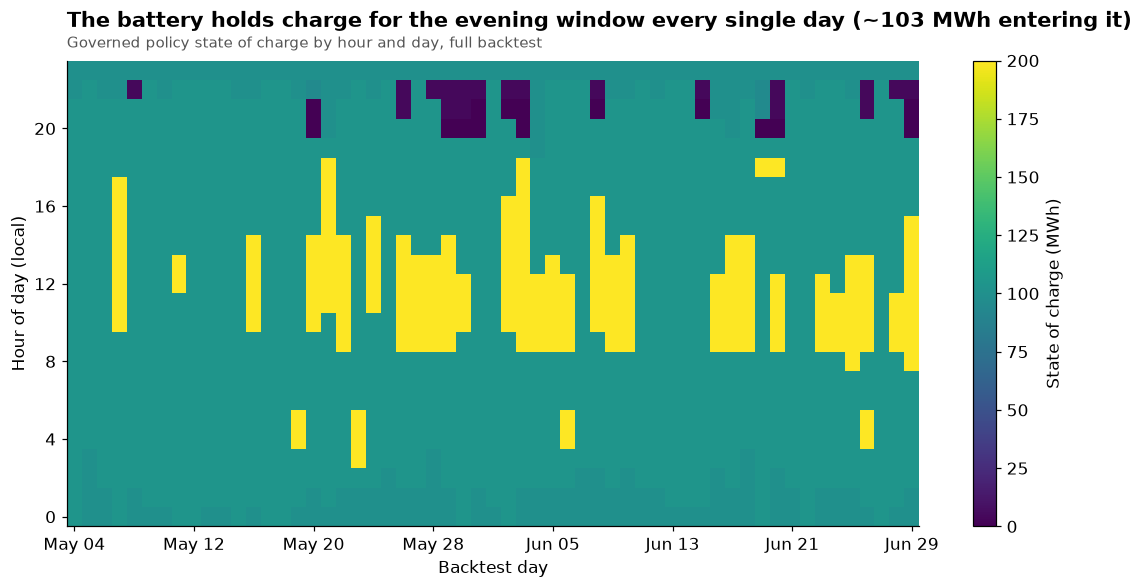

In [6]:
fig = backtest_viz.fig21_soc_heatmap(governed_schedule)

### Interpretation — fig21

The proof the behavior is systematic: across every backtest day, state of charge builds through the cheap hours and stands high entering the evening scarcity window (17:00–20:00), then drains into it. This is the strategy fig16 (price heatmap) said the market pays for, executed daily by an agent that never saw tomorrow's prices. **Business consequence:** an operator can trust behavior that is legible and repeatable — this heatmap is what 'the battery holds charge for the evening' looks like as evidence instead of a slogan.

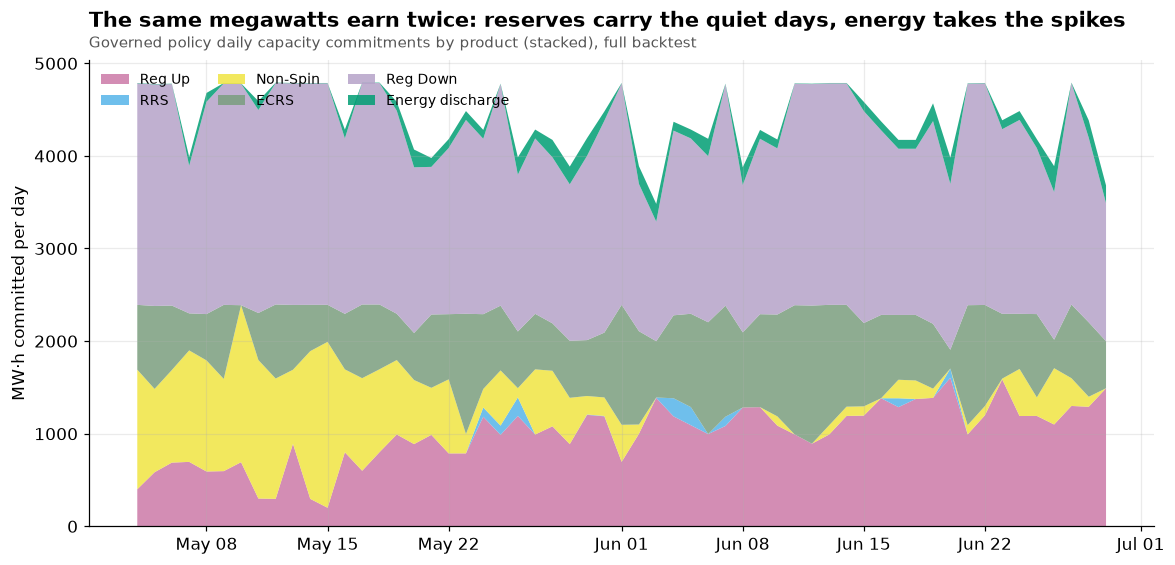

In [7]:
fig = backtest_viz.fig22_reserve_allocation(governed_schedule)

### Interpretation — fig22

How the same megawatts earn twice: on calm days the battery's capacity is rented out almost entirely as reserves (steady income); on stressed days energy discharge takes over the profile. The allocation shifts automatically with the forecast — no rule was hand-written for it. **Business consequence:** this adaptive reallocation is precisely the value RTC+B-style co-optimization is designed to unlock, demonstrated on real prices.

C:\Users\alanm\OneDrive\Área de Trabalho\Forecast to Dispatch\src\forecast_to_dispatch\viz\backtest_viz.py:228: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month = daily.index.to_period("M")


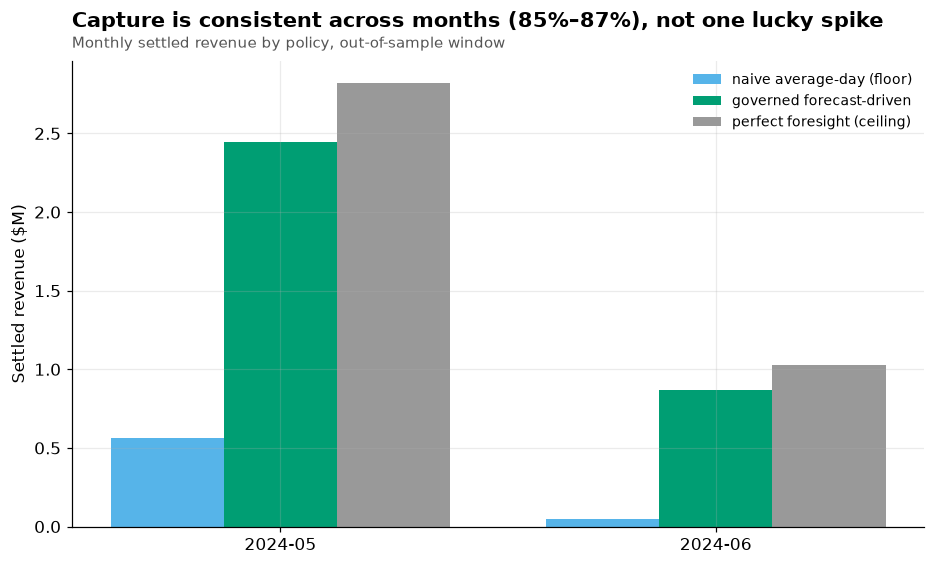

In [8]:
fig = backtest_viz.fig23_monthly_revenue(daily)

### Interpretation — fig23

Both months show the same structure — governed near the ceiling, far above naive — so the 86% capture is not one lucky May afternoon. June, with fewer extreme spikes, actually shows *higher* relative capture; spikier months widen the gap to perfection while raising absolute revenue. **Business consequence:** consistency across market regimes is what separates a strategy from a story; two months is the honest limit of this study window, and the drift monitor (Phase 6) is the tool that watches whether the pattern persists.

## Takeaways

| Claim | Evidence |
|---|---|
| The agent makes real money on real prices | $3.31M settled over 57 days |
| Honestly measured | dispatched on forecasts, settled on realized; ceiling & floor reported |
| 86% of available value captured | fig07/fig08 |
| Stacking is most of the value | AS = 96% of gross revenue (fig09) |
| Cost of imperfection quantified | fig10; top-5 days = 49% of the gap |
| Behavior is systematic | fig21/fig22 |

Next: `06_governance_walkthrough.ipynb` — the layer that makes this deployable: model card, risk register, drift monitoring, an append-only audit trail, human-in-the-loop approval, and rollback.